In [1]:
#!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 128.9 MB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.4/303.4 MB 153.8 MB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]


Accuracy: 0.71875


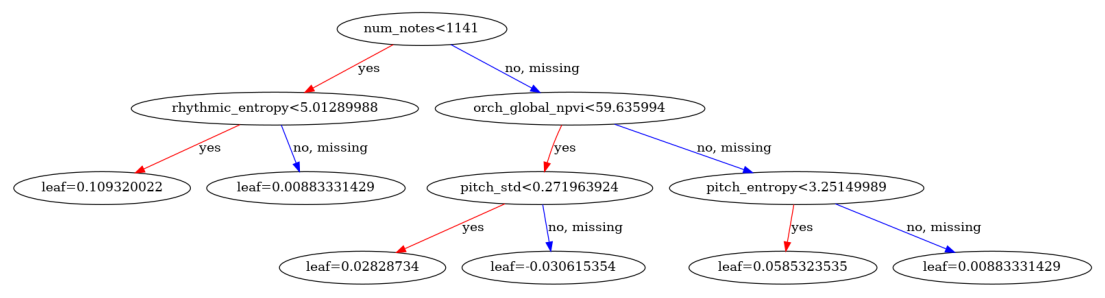

New Predictions: [0 7 1 1 1 0 1 0 1 1]
New Probabilities: [[0.84159    0.05446362 0.00988478 0.00502799 0.05348015 0.00192154
  0.00283923 0.00964011 0.00443201 0.01672051]
 [0.07115973 0.28467208 0.04263812 0.01471073 0.01287615 0.00562198
  0.010597   0.5007614  0.00595721 0.05100561]
 [0.11011035 0.55557245 0.04659759 0.01207996 0.01057346 0.00544705
  0.0087019  0.20325969 0.00577346 0.0418841 ]
 [0.03389871 0.7721906  0.01377703 0.00700782 0.00580365 0.00477987
  0.00326769 0.01349328 0.00268913 0.14309229]
 [0.10757089 0.7007618  0.03029633 0.01369989 0.01139478 0.00523567
  0.00803307 0.05832626 0.00554786 0.0591334 ]
 [0.8834839  0.0571748  0.01037684 0.00527828 0.0043713  0.0030531
  0.00309497 0.01011999 0.00465264 0.01839422]
 [0.10215794 0.28442964 0.03153564 0.01365793 0.22671498 0.00670067
  0.00781269 0.2728052  0.00553087 0.04865443]
 [0.85390246 0.08412886 0.0105257  0.00510155 0.00422494 0.00271505
  0.00299135 0.00978115 0.00449685 0.02213212]
 [0.03537779 0.8756705 

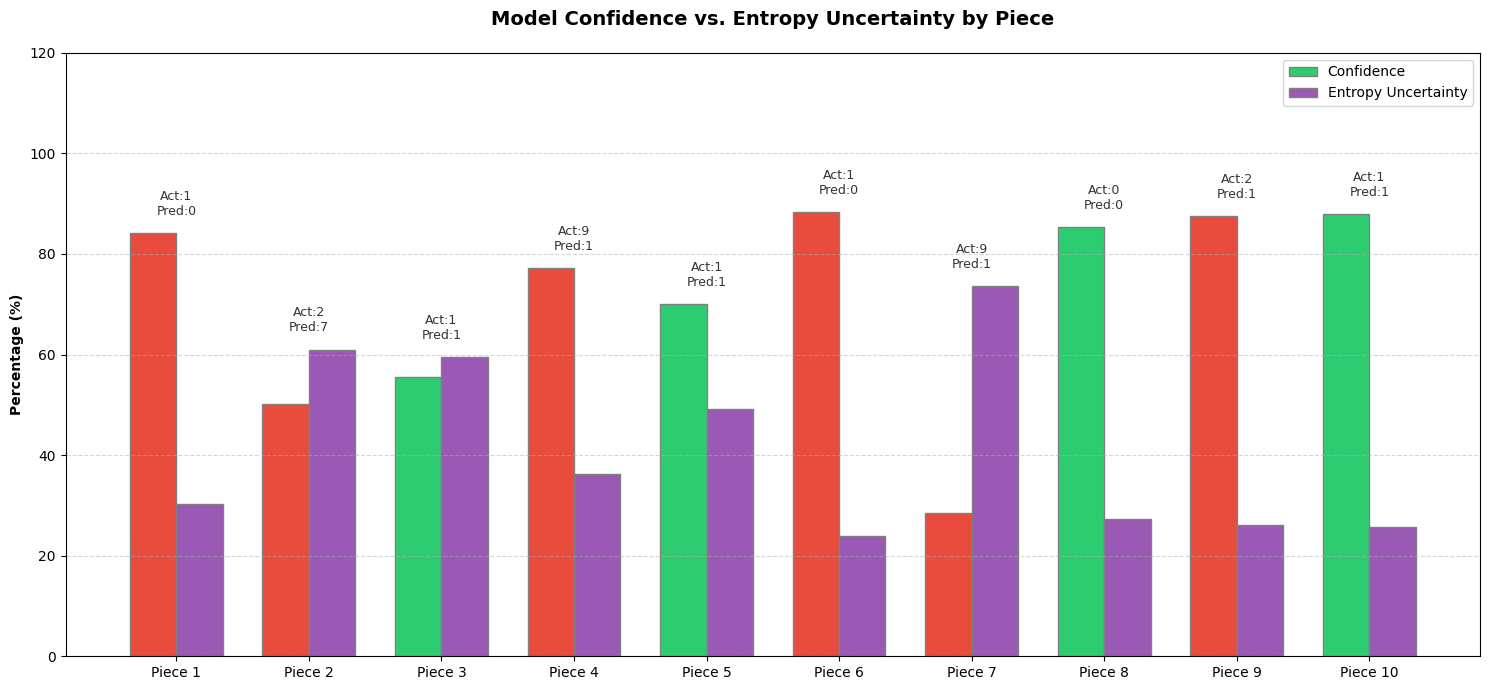

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
from scipy.stats import entropy
features = ["pitch_entropy","rhythmic_entropy","average_interval_size","average_vertical_density","average_polyphonic_voices","fractal_dimension","num_notes","pitch_std","pitch_range","number_of_instruments","unique_note_values","average_beat_gap","most_common_note","average_note_length","largest_leap","orch_outer_voice_motion_index","orch_harmonic_change_entropy","orch_global_npvi"]

df = pd.read_csv('train_data.csv')

X_train, X_test, y_train, y_test = train_test_split(df[features], df["composer_label"], test_size=0.2, random_state=42)
# Train XGBoost Classifier
model = XGBClassifier(n_estimators=50, objective='multi:softprob', eval_metric="logloss", max_depth=3, num_class=10, learning_rate=0.05)
model.fit(X_train, y_train)
# Predictions and accuracy
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
# plt.figure(figsize=(30,20))
# plot_tree(model, num_trees=0)
# plt.show()

fig, ax = plt.subplots(figsize=(14, 9))   # you can also pass `sharex`, `sharey`, etc.

plot_tree(model, ax=ax)   # TB = top‑to‑bottom (default)
plt.show()


test_df = pd.read_csv('test_data_clean.csv')
separate_preds = model.predict(test_df[features])
separate_probs = model.predict_proba(test_df[features])

print("New Predictions:", separate_preds)
print("New Probabilities:", separate_probs)


num_pieces = 10
test_subset_probs = separate_probs[:num_pieces]
test_subset_preds = separate_preds[:num_pieces]

y_true_subset = df["composer_label"].iloc[:num_pieces].values 

confidence = np.max(test_subset_probs, axis=1) * 100

base_entropy = entropy(test_subset_probs, axis=1, base=2)
max_possible_entropy = np.log2(10) # 10 classes
entropy_uncertainty = (base_entropy / max_possible_entropy) * 100

x = np.arange(num_pieces)
width = 0.35 

fig, ax = plt.subplots(figsize=(15, 7))

conf_colors = ['#2ECC71' if p == t else '#E74C3C' for p, t in zip(test_subset_preds, y_true_subset)]
entropy_color = '#9B59B6'  

rects1 = ax.bar(x - width/2, confidence, width, label='Confidence', color=conf_colors, edgecolor='grey')
rects2 = ax.bar(x + width/2, entropy_uncertainty, width, label='Entropy Uncertainty', color=entropy_color, edgecolor='grey')

for i in range(num_pieces):
    act_label = y_true_subset[i]
    pred_label = test_subset_preds[i]
    
    max_y = max(confidence[i], entropy_uncertainty[i])
    ax.text(i, max_y + 3, f'Act:{act_label}\nPred:{pred_label}', 
            ha='center', va='bottom', fontsize=9, color='#333333')

ax.set_ylabel('Percentage (%)', fontweight='bold')
ax.set_title('Model Confidence vs. Entropy Uncertainty by Piece', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels([f'Piece {i+1}' for i in range(num_pieces)])
ax.set_ylim(0, 120)  # Extra headroom for labels

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ECC71', edgecolor='grey', label='Confidence'),
    Patch(facecolor='#9B59B6', edgecolor='grey', label='Entropy Uncertainty')
]
ax.legend(handles=legend_elements, loc='upper right')

ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [9]:
import numpy as np
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split

# 2. Define the base XGBoost model
# base_xgb = xgb.XGBClassifier(
#     n_estimators=50,
#     max_depth=3,
#     learning_rate=0.1,
#     subsample=0.8,         # Row subsampling for extra variance
#     colsample_bytree=0.8,  # Feature subsampling for extra variance
#     eval_metric='logloss'
# )
base_xgb = XGBClassifier(n_estimators=50, objective='multi:softprob', eval_metric="logloss", max_depth=3, num_class=10, learning_rate=0.05, subsample=0.8)


# 3. Wrap it in a BaggingClassifier to generate the ensemble automatically
ensemble = BaggingClassifier(
    estimator=base_xgb,
    n_estimators=10,       # Number of bootstrap models to evaluate
    bootstrap=True,        # Sample with replacement
    max_samples=0.8,       # Train each model on 80% of data
    n_jobs=-1,             # Use all available CPU cores
    random_state=42
)

# 4. Train the entire ensemble
ensemble.fit(X_train, y_train)

# 5. Extract predictions from every underlying bootstrap model
# shape: (n_estimators, n_samples, n_classes)
all_model_probs = np.array([model.predict_proba(X_test) for model in ensemble.estimators_])

# 6. Isolate the target class (Class 1) probabilities
# shape: (n_estimators, n_samples)
class_1_probs = all_model_probs[:, :, 1]

# 7. Compute the mean and standard deviation (uncertainty metric)
mean_probabilities = np.mean(class_1_probs, axis=0)
uncertainty_std = np.std(class_1_probs, axis=0)

# 8. Print out results for verification
for idx in range(5):
    print(f"Sample {idx}:")
    print(f"  -> Ensemble Mean Probability: {mean_probabilities[idx]:.4f}")
    print(f"  -> Prediction Uncertainty (Std Dev): {uncertainty_std[idx]:.4f}\n")
    print(uncertainty_std.mean())


Sample 0:
  -> Ensemble Mean Probability: 0.8134
  -> Prediction Uncertainty (Std Dev): 0.0556

0.094217904
Sample 1:
  -> Ensemble Mean Probability: 0.5313
  -> Prediction Uncertainty (Std Dev): 0.0800

0.094217904
Sample 2:
  -> Ensemble Mean Probability: 0.1820
  -> Prediction Uncertainty (Std Dev): 0.1065

0.094217904
Sample 3:
  -> Ensemble Mean Probability: 0.4172
  -> Prediction Uncertainty (Std Dev): 0.1811

0.094217904
Sample 4:
  -> Ensemble Mean Probability: 0.8314
  -> Prediction Uncertainty (Std Dev): 0.0468

0.094217904
